# 04 — Results & Comparison
Load checkpoints từ tất cả các fold, tính BCC + AUC, và so sánh với kết quả bài báo.

In [4]:
import sys, os, glob
sys.path.insert(0, '..')

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
import torch.nn.functional as F

from skin_pipeline.utils import SkinLesionDataset, SkinLesionModel, get_transforms, CLASSES, NUM_CLASSES
import warnings; warnings.filterwarnings('ignore')

DATA_DIR  = os.path.expanduser('~/.cache/kagglehub/datasets/mahdavi1202/skin-cancer/versions/1')
CSV_PATH  = 'processed_metadata.csv'
CKPT_DIR  = 'checkpoints'
LOG_DIR   = 'logs'
BATCH_SIZE = 30
IMG_SIZE   = 224
N_FOLDS    = 5
device     = torch.device('cuda' if torch.cuda.is_available() else
                           'mps'  if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {device}')

Device: mps


## 1. Evaluate từng Fold

In [5]:
def evaluate_fold(backbone, meta_dim, use_metablock, fold, df, feature_cols):
    # Tìm checkpoint tốt nhất
    ckpt_pattern = f'{CKPT_DIR}/fold{fold}/*.ckpt'
    ckpts = glob.glob(ckpt_pattern)
    if not ckpts:
        print(f'  Fold {fold}: no checkpoint found — skip')
        return None, None

    ckpt_path = sorted(ckpts)[-1]

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    _, val_idx = list(skf.split(df, df['diagnostic_idx']))[fold]

    val_ds = SkinLesionDataset(
        DATA_DIR, df.iloc[val_idx].copy(), feature_cols,
        transform=get_transforms(IMG_SIZE, train=False))
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    # Load model từ checkpoint
    # Load trực tiếp state_dict thô vào SkinLesionModel (không cần Lightning Module)
    ckpt = torch.load(ckpt_path, map_location='cpu')
    state_dict = {k.replace('model.', ''): v for k, v in ckpt['state_dict'].items() if k.startswith('model.')}
    
    lit = SkinLesionModel(backbone, meta_dim, use_metablock=use_metablock)
    lit.load_state_dict(state_dict)
    lit.eval().to(device)

    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for img, meta, y in val_loader:
            logits = lit(img.to(device), meta.to(device))
            probs  = F.softmax(logits, dim=1).cpu().numpy()
            preds  = np.argmax(probs, axis=1)
            all_probs.append(probs)
            all_preds.extend(preds)
            all_labels.extend(y.numpy())

    all_probs  = np.vstack(all_probs)
    all_labels = np.array(all_labels)
    all_preds  = np.array(all_preds)

    bcc = balanced_accuracy_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
    print(f'  Fold {fold} → BCC: {bcc:.4f} | AUC: {auc:.4f}')
    return bcc, auc

In [6]:
df_full   = pd.read_csv(CSV_PATH)
IGNORE    = {'patient_id','lesion_id','diagnostic','diagnostic_idx','img_id'}
feat_cols = [c for c in df_full.columns if c not in IGNORE]
meta_dim  = len(feat_cols)

# ── Chọn model để đánh giá ────────────────────────────────────────────────────
BACKBONE      = 'pit_s_distilled_224'
USE_METABLOCK = True

results = []
print(f'Evaluating: {BACKBONE} | MetaBlock={USE_METABLOCK}')
for fold in range(N_FOLDS):
    bcc, auc = evaluate_fold(BACKBONE, meta_dim, USE_METABLOCK, fold, df_full, feat_cols)
    results.append({'fold': fold, 'BCC': bcc, 'AUC': auc})

results_df = pd.DataFrame(results)
results_df.loc['Mean'] = results_df[['BCC','AUC']].mean()
results_df.loc['Std']  = results_df[['BCC','AUC']].std()
display(results_df.round(4))

Evaluating: pit_s_distilled_224 | MetaBlock=True
  Fold 0 → BCC: 0.6372 | AUC: 0.9088
  Fold 1 → BCC: 0.6473 | AUC: 0.9037
  Fold 2 → BCC: 0.6511 | AUC: 0.9074


  Fold 3 → BCC: 0.6346 | AUC: 0.8931
  Fold 4 → BCC: 0.6222 | AUC: 0.9105


,fold,BCC,AUC
0,0.0,0.6372,0.9088
1,1.0,0.6473,0.9037
2,2.0,0.6511,0.9074
3,3.0,0.6346,0.8931
4,4.0,0.6222,0.9105
Mean,NaN,0.6385,0.9047
Std,NaN,0.0102,0.0062


## 3. Training Curves (tất cả fold từ log CSV)

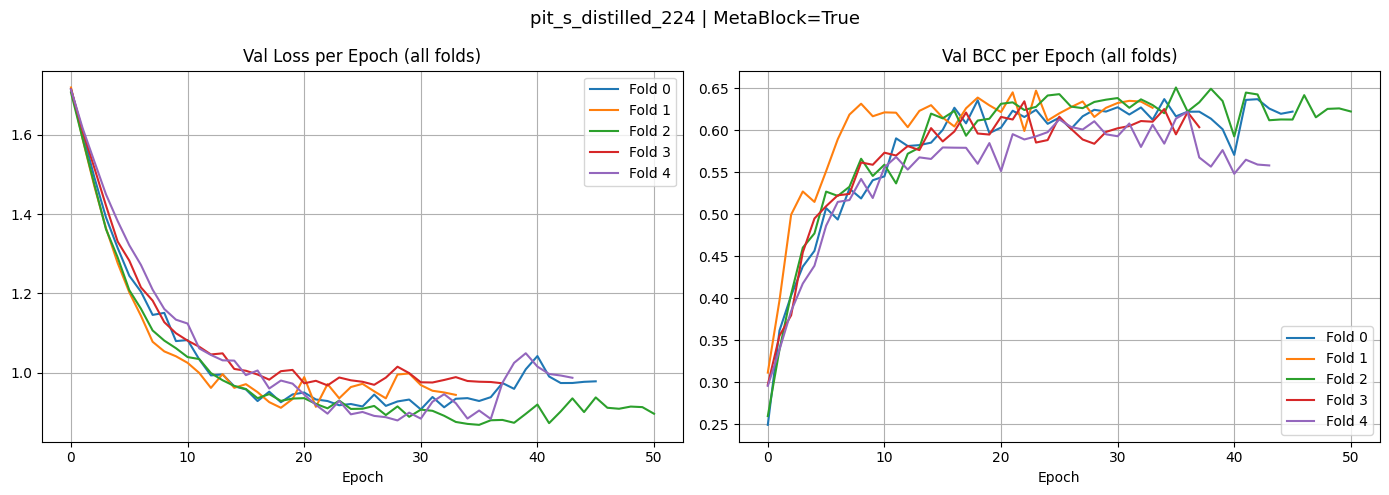

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for fold in range(N_FOLDS):
    logs = sorted(glob.glob(f'{LOG_DIR}/{BACKBONE}_fold{fold}/version_*/metrics.csv'))
    if not logs: continue
    m = pd.read_csv(logs[-1]).groupby('epoch').last().reset_index()
    axes[0].plot(m['epoch'], m['val_loss'], label=f'Fold {fold}')
    axes[1].plot(m['epoch'], m['val_bcc'],  label=f'Fold {fold}')

axes[0].set_title('Val Loss per Epoch (all folds)'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True)
axes[1].set_title('Val BCC per Epoch (all folds)');  axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True)
plt.suptitle(f'{BACKBONE} | MetaBlock={USE_METABLOCK}', fontsize=13)
plt.tight_layout(); plt.show()